In [7]:
import json

import h5py
import matplotlib.pyplot as plt
import numba
import numpy as np

from lib.plots import set_axis

In [30]:
config_id = 4
filename = f"_outputs/output-{config_id}.h5"

with h5py.File(filename, "r") as store:
    phase_store = store["production"]
    config = json.loads(phase_store["metadata/config_source"][()])

    positions_history = []
    for step_key in phase_store[".steps"]:
        positions = phase_store[step_key]["positions"][:]
        positions_history.append(positions)
    positions_history = np.array(positions_history)

In [31]:
@numba.njit
def accumulate_contacts(
    contact_matrix: np.ndarray,
    positions: np.ndarray,
    contact_distance: float,
):
    n = positions.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            distance = np.linalg.norm(positions[i] - positions[j])
            if distance < contact_distance:
                contact_matrix[i, j] += 1
                contact_matrix[j, i] += 1

In [32]:
chain_length = positions_history.shape[1]
contact_matrix = np.zeros((chain_length, chain_length))

for positions in positions_history:
    accumulate_contacts(contact_matrix, positions, contact_distance=1.5)
contact_matrix /= len(positions_history)

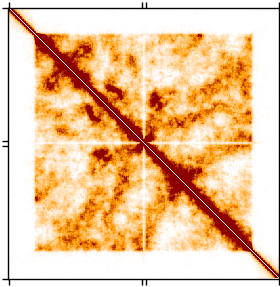

In [33]:
fir, ax = plt.subplots()
ax.matshow(contact_matrix, vmin=0, vmax=0.05, cmap="wrr")
ticks = [0, 197, 203, 400]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels([])
ax.set_yticklabels([])
pass

In [34]:
config["chains"][0]

{'length': 400,
 'association_features': [{'site': {'start': 0, 'end': 40},
   'valency': 0,
   '@what': 'active region'},
  {'site': {'start': 199, 'end': 202}, 'valency': 0, '@what': 'domain linker'},
  {'site': {'start': 360, 'end': 400},
   'valency': 0,
   '@what': 'active region'}],
 'extruder_features': [{'site': 198,
   'loading': 0,
   'arrival': 0,
   '@what': 'domain boundary'},
  {'site': 202, 'loading': 0, 'arrival': 0, '@what': 'domain boundary'}]}